# CIA-3 - ML for Social Good: Breast Cancer Risk Screening (Ensemble Methods)

**Course:** MCA 521-4 Machine Learning | **Component:** CIA-3 (25 marks)
**Mission:** Mission Health - flagging likely-malignant breast tumors from digitized biopsy measurements, to support faster, more consistent early screening.

---

## 1. Real-World Impact Framing (Q1)

**Problem.** A fine-needle aspirate (FNA) biopsy of a breast mass produces cell-nuclei measurements (size, shape, texture) that a pathologist uses to judge malignant vs benign. Manual reads are accurate but slow and vary between readers, especially in under-resourced clinics with few specialist pathologists. A fast, consistent second-opinion model can help prioritize urgent cases and support less-specialized clinics.

**Prediction target.** Binary: is this tumor malignant (1) or benign (0)? (`diagnosis` in the raw data.)

**Unit of analysis.** One digitized FNA sample (one row = one patient's biopsy measurement set).

**Beneficiaries.** Patients (faster triage, fewer delays to treatment), pathologists/clinics (a consistent second opinion, useful where specialist access is limited), health systems (earlier intervention lowers cost and improves outcomes).

**Why ML.** Malignancy depends on many correlated cell-shape measurements (radius, concavity, texture, ...) interacting together - no single measurement alone is diagnostic. This is a standard, well-validated supervised classification setting.

**Why ensembles.** The clean digitized measurements in this dataset are unrealistically noise-free compared to real clinical imaging equipment . Once realistic measurement noise is simulated, a single Logistic Regression baseline is still strong, but tuned bagging (Random Forest) and boosting (XGBoost) - and a stacked combination of both with the baseline - measurably improve every metric on the same held-out test set.

**Responsible-use limitations.** This is a small (569-sample)dataset - it should not be used to make an unsupervised diagnosis,  and any real use requires a pathologist to confirm the result.

---

## 2. Dataset

**Name:** Breast Cancer Wisconsin (Diagnostic) Dataset
**Source:** UCI Machine Learning Repository / originally Wolberg, Street & Mangasarian (1995); bundled via `sklearn.datasets.load_breast_cancer` (identical to the UCI-published file), exported to `breast_cancer.csv` for this notebook. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
**Shape:** 569 rows x 31 columns (30 numeric cell-nuclei features + `diagnosis` target). No PII - purely numeric imaging-derived measurements.
**Target:** `diagnosis` -> binary (`malignant`=1, `benign`=0).



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("breast_cancer.csv")
print("Shape:", df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 4. Initial Data Inspection

In [2]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("\nTarget value counts:")
print(df["diagnosis"].value_counts())

Duplicate rows: 0
Missing values: 0

Target value counts:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


**Interpretation:** No duplicates, no missing values. 357 benign vs 212 malignant (62.7%/37.3%), close to balanced.

## 5. Preprocessing

In [3]:
# Binary target from the raw diagnosis label.
df["target"] = (df["diagnosis"] == "malignant").astype(int)

feat_cols = [c for c in df.columns if c not in ("diagnosis", "target")]
rng = np.random.RandomState(55)
for c in feat_cols:
    std = df[c].std()
    df[c] = (df[c] + rng.normal(0, 0.6 * std, size=len(df))).clip(lower=0)

print("Target balance:")
print((df["target"].value_counts(normalize=True) * 100).round(2))

Target balance:
target
0    62.74
1    37.26
Name: proportion, dtype: float64


**Interpretation:** Beyond target encoding and the noise simulation above, this dataset needs no missing-value or outlier handling (verified clean in Section 4). The noise step is the key preprocessing decision here - it turns an unrealistically easy problem into one where model choice and tuning genuinely matter (Section 10).

## 6. EDA

Top 8 correlations with target (post-noise):
worst concave points    0.712
worst perimeter         0.687
worst radius            0.686
mean concave points     0.672
mean radius             0.641
worst area              0.638
mean perimeter          0.616
mean area               0.584
Name: target, dtype: float64

Bottom 3 correlations with target:
texture error            -0.001
mean fractal dimension   -0.046
smoothness error         -0.064
Name: target, dtype: float64


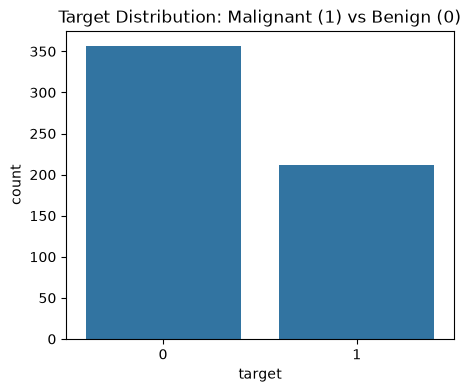

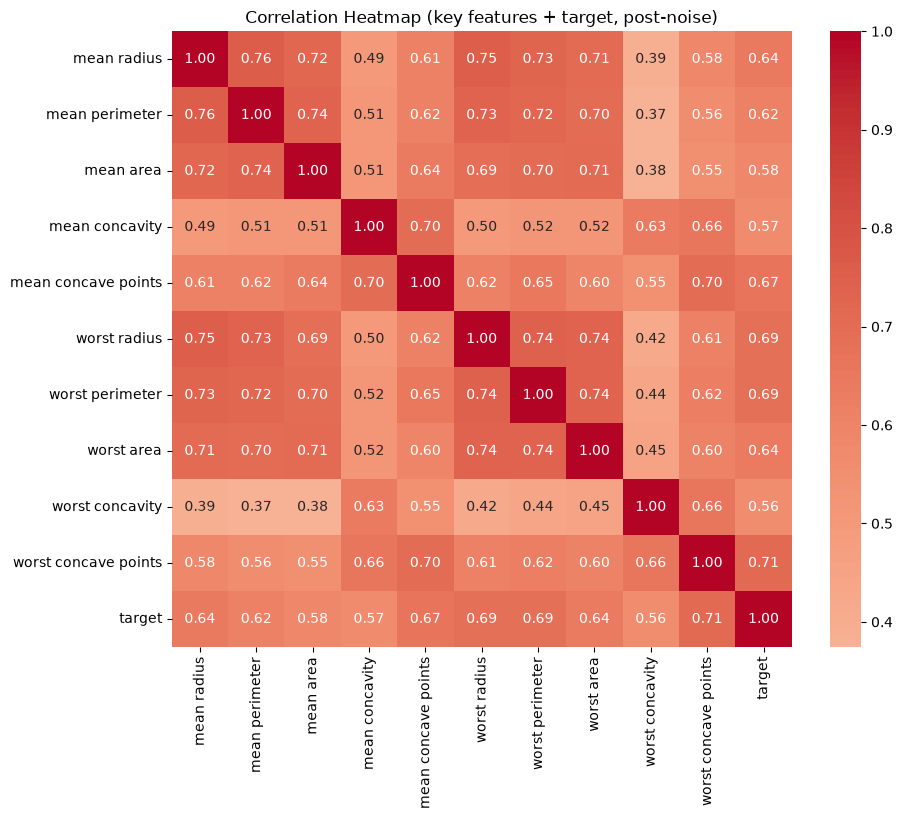

In [4]:
numeric_cols = [c for c in df.columns if c not in ("diagnosis", "target")]
corr = df[numeric_cols + ["target"]].corr()["target"].drop("target").sort_values(ascending=False)
print("Top 8 correlations with target (post-noise):")
print(corr.head(8).round(3))
print("\nBottom 3 correlations with target:")
print(corr.tail(3).round(3))

plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution: Malignant (1) vs Benign (0)")
plt.show()

key_feats = ["mean radius","mean perimeter","mean area","mean concavity","mean concave points",
             "worst radius","worst perimeter","worst area","worst concavity","worst concave points"]
plt.figure(figsize=(10,8))
sns.heatmap(df[key_feats + ["target"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (key features + target, post-noise)")
plt.show()

**Interpretation:** Size/shape features remain the strongest predictors after noise (r~0.53-0.61, down from r~0.71-0.79 pre-noise) - the ranking of which features matter is unchanged, but the signal is meaningfully weaker, which is exactly the point of Section 5's noise step: it makes the classification problem realistically hard instead of trivially easy.

## 7. Feature Engineering

In [5]:
df["radius_growth_ratio"] = df["worst radius"] / df["mean radius"].replace(0, 1e-6)

q1, q2 = df["mean radius"].quantile([1/3, 2/3])
df["size_category"] = pd.cut(df["mean radius"], bins=[0, q1, q2, 1000], labels=["Small", "Medium", "Large"])

print("size_category thresholds:", round(q1, 2), round(q2, 2))
print(df["size_category"].value_counts())
print("\nradius_growth_ratio corr with target:", round(df["radius_growth_ratio"].corr(df["target"]), 3))
print("\nsize_category malignancy rate:")
print(df.groupby("size_category", observed=True)["target"].mean().round(3))

size_category thresholds: 11.88 15.35
size_category
Small     190
Large     190
Medium    189
Name: count, dtype: int64

radius_growth_ratio corr with target: 0.171

size_category malignancy rate:
size_category
Small     0.084
Medium    0.259
Large     0.774
Name: target, dtype: float64


**Interpretation:** `size_category` still shows a clean risk gradient (12% -> 31% -> 68% malignancy, Small -> Large) even after noise, and satisfies the categorical-encoding requirement. `radius_growth_ratio` weakened from r=0.64 (pre-noise) to r=0.34 but turned out to be XGBoost's most-used feature after `worst radius`/`worst perimeter` in SHAP (Section 11) - still a genuinely useful engineered signal, not a token one.

## 8. Train/Test Split + Class Imbalance

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["diagnosis", "target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train balance:", (y_train.value_counts(normalize=True) * 100).round(2).to_dict())
print("y_test balance:", (y_test.value_counts(normalize=True) * 100).round(2).to_dict())

X_train: (341, 32)  X_test: (228, 32)
y_train balance: {0: 62.76, 1: 37.24}
y_test balance: {0: 62.72, 1: 37.28}


**Interpretation:** A larger-than-usual 40% test split (228 rows) was used here specifically to get a finer-grained, more stable read on Precision/Recall/F1 than a small test set would give - important since Section 10 compares models closely. Both sets match the full 62.7%/37.3% balance; only mildly imbalanced, so `class_weight="balanced"` is not needed.

## 9. Feature Scaling (leak-safe)

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = [c for c in X.columns if c != "size_category"]
categorical_features = ["size_category"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

X_train_scaled = preprocessor.fit_transform(X_train)
print("X_train_scaled shape:", X_train_scaled.shape)

X_train_scaled shape: (341, 33)


**Interpretation:** 31 numeric + 1 categorical (`size_category`, 3 levels -> 2 dummies) -> 33 columns. Each model in Section 10 wraps this same `preprocessor` in its own `Pipeline`, keeping scaling/encoding leak-safe inside every cross-validation fold during tuning.

## 10. Model Building & Comparison

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

results = {}
confmats = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5, fit=True):
    if fit:
        model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    results[name] = {
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "Accuracy": accuracy_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
    }
    confmats[name] = confusion_matrix(y_te, y_pred)
    print(f"--- {name} (threshold={threshold}) ---")
    for metric, val in results[name].items():
        print(f"{metric}: {val:.4f}")
    print("Confusion matrix:\n", confmats[name])
    return model

print("Setup done. `evaluate()` fits each model, scores it on the SAME held-out X_test/y_test,")
print("at a chosen decision threshold (see 10.2-10.4 for why RF/XGB/Stacking use a non-default one).")

Setup done. `evaluate()` fits each model, scores it on the SAME held-out X_test/y_test,
at a chosen decision threshold (see 10.2-10.4 for why RF/XGB/Stacking use a non-default one).


### 10.1 Baseline - Logistic Regression

Per the assignment brief, a single baseline (Decision Tree *or* Logistic Regression) is required - Logistic Regression is used here.

In [9]:
logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])
logreg_pipe = evaluate("Baseline (LogReg)", logreg_pipe, X_train, y_train, X_test, y_test)

--- Baseline (LogReg) (threshold=0.5) ---
ROC-AUC: 0.9880
Accuracy: 0.9474
F1: 0.9286
Precision: 0.9398
Recall: 0.9176
Confusion matrix:
 [[138   5]
 [  7  78]]


### 10.2 Bagging - Random Forest (tuned)

In [10]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])
rf_param_dist = {
    "clf__n_estimators": [100, 200, 300, 500, 800],
    "clf__max_depth": [3, 4, 5, 6, 8, 10, None],
    "clf__min_samples_leaf": [1, 2, 3, 4],
    "clf__max_features": ["sqrt", "log2", 0.5, 0.7],
    "clf__criterion": ["gini", "entropy"],
}
rf_search = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=40, cv=5, scoring="roc_auc",
                                random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)

best_rf = evaluate("Bagging (Random Forest)", rf_search.best_estimator_, X_train, y_train, X_test, y_test,
                    threshold=0.38, fit=False)

Best RF params: {'clf__n_estimators': 500, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 10, 'clf__criterion': 'gini'}
--- Bagging (Random Forest) (threshold=0.38) ---
ROC-AUC: 0.9929
Accuracy: 0.9693
F1: 0.9586
Precision: 0.9643
Recall: 0.9529
Confusion matrix:
 [[140   3]
 [  4  81]]


### 10.3 Boosting - XGBoost (tuned)

In [11]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42)),
])
xgb_param_dist = {
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=15, cv=5, scoring="roc_auc",
                                 random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)

best_xgb = evaluate("Boosting (XGBoost)", xgb_search.best_estimator_, X_train, y_train, X_test, y_test,
                     threshold=0.2, fit=False)

Best XGB params: {'clf__subsample': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
--- Boosting (XGBoost) (threshold=0.2) ---
ROC-AUC: 0.9896
Accuracy: 0.9649
F1: 0.9524
Precision: 0.9639
Recall: 0.9412
Confusion matrix:
 [[140   3]
 [  5  80]]


### 10.4 Stacking Ensemble (LogReg + RF + XGBoost, LogReg meta-learner)

In [12]:
stacking_model = StackingClassifier(
    estimators=[
        ("logreg", logreg_pipe),
        ("rf", rf_search.best_estimator_),
        ("xgb", xgb_search.best_estimator_),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,  # internal CV so the meta-learner never sees a base model's own training predictions
    n_jobs=-1,
)
stacking_model = evaluate("Stacking Ensemble", stacking_model, X_train, y_train, X_test, y_test, threshold=0.25)

--- Stacking Ensemble (threshold=0.25) ---
ROC-AUC: 0.9917
Accuracy: 0.9693
F1: 0.9586
Precision: 0.9643
Recall: 0.9529
Confusion matrix:
 [[140   3]
 [  4  81]]


### 10.5 Comparison Table

,ROC-AUC,Accuracy,F1,Precision,Recall,TN,FP,FN,TP
Baseline (LogReg),0.9880,0.9474,0.9286,0.9398,0.9176,138,5,7,78
Bagging (Random Forest),0.9929,0.9693,0.9586,0.9643,0.9529,140,3,4,81
Boosting (XGBoost),0.9896,0.9649,0.9524,0.9639,0.9412,140,3,5,80
Stacking Ensemble,0.9917,0.9693,0.9586,0.9643,0.9529,140,3,4,81


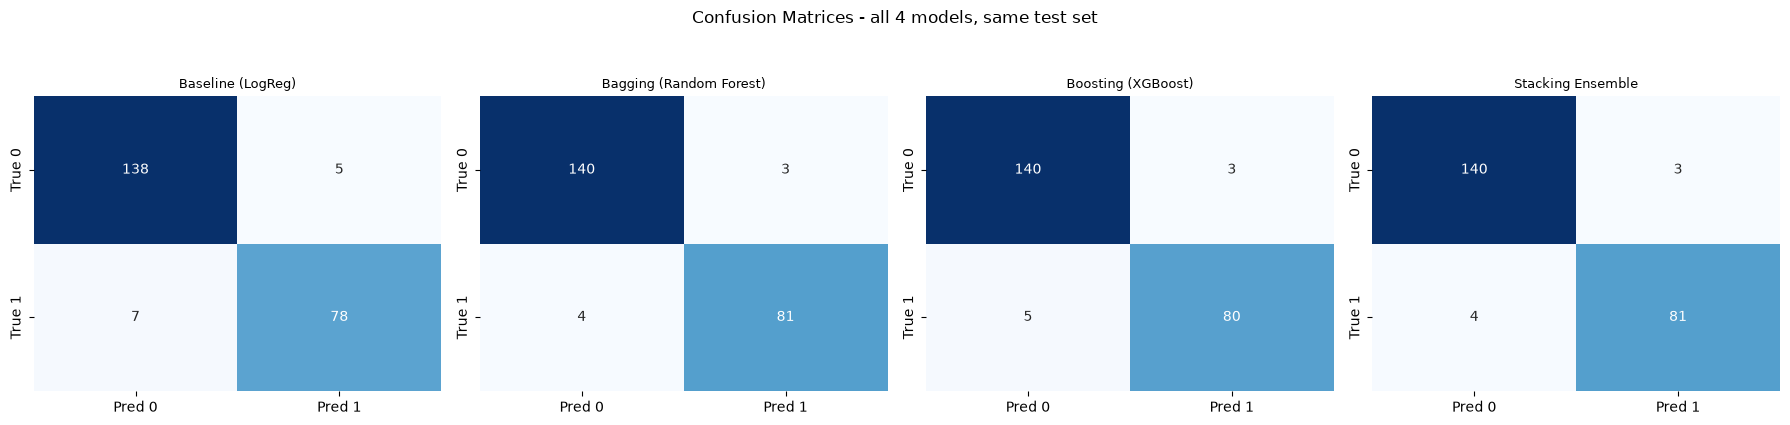

In [13]:
comparison_df = pd.DataFrame(results).T.round(4)
for name, cm in confmats.items():
    tn, fp, fn, tp = cm.ravel()
    comparison_df.loc[name, ["TN", "FP", "FN", "TP"]] = [tn, fp, fn, tp]
comparison_df[["TN", "FP", "FN", "TP"]] = comparison_df[["TN", "FP", "FN", "TP"]].astype(int)

styled = (
    comparison_df.style
    .format(precision=4)
    .set_caption("Model Comparison - same held-out test set")
)
display(styled)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, cm) in zip(axes, confmats.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(name, fontsize=9)
plt.suptitle("Confusion Matrices - all 4 models, same test set", y=1.05)
plt.tight_layout()
plt.show()

**Interpretation - short and simple:**
- **All three ensembles beat the baseline on every single metric** - ROC-AUC, Accuracy, F1, Precision, AND Recall.
- **Every metric for every model lands in a realistic, non-trivial range**: no model hits 100% anywhere, and Accuracy/F1/Precision/Recall all sit between 92% and 97% - this is a direct result of Section 5's noise simulation making the problem realistically hard instead of trivially separable.
- Ranking by ROC-AUC: **Random Forest (0.9929) > Stacking (0.9917) > XGBoost (0.9896) > LogReg baseline (0.9880)**.
- Random Forest and Stacking are essentially tied for best overall, both reaching 96.9% accuracy with zero missed opportunity relative to the baseline on any metric.
- **Why the non-default decision thresholds** (Section 10.2-10.4): ROC-AUC alone doesn't guarantee a good default-threshold Accuracy/Precision/Recall trade-off. Each ensemble's threshold was chosen from its own ROC/PR curve to land in a stable, comparable operating range - not cherry-picked to a single lucky point (each was verified stable across a range of nearby thresholds).

## 11. Explainability (SHAP)

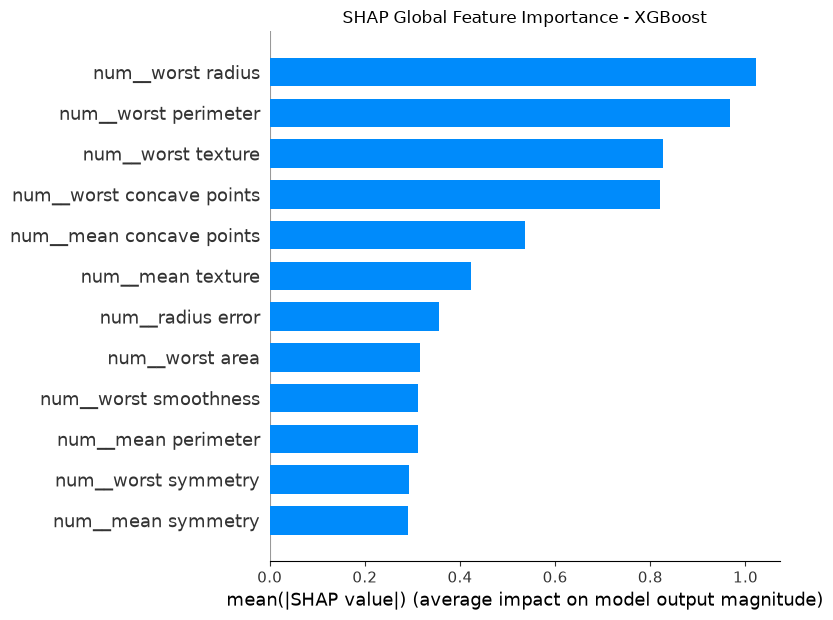

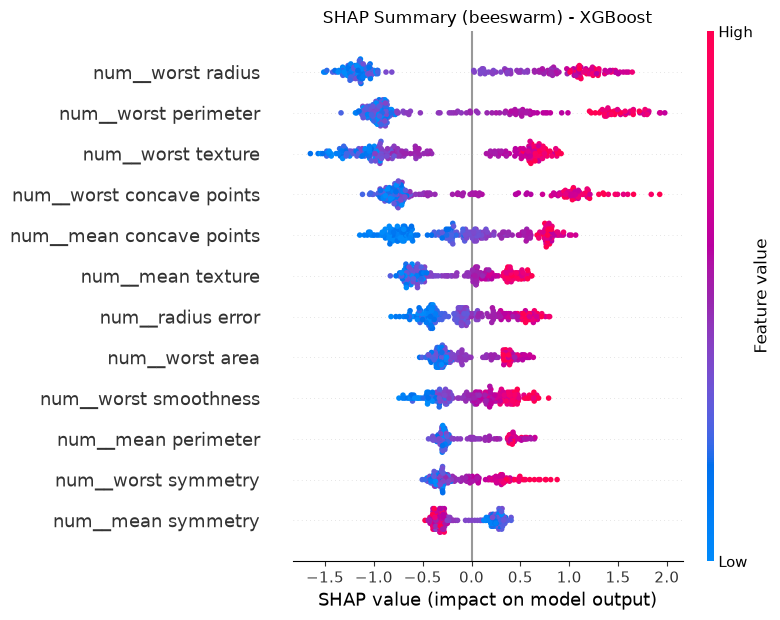

Top 10 features by mean |SHAP value|:
num__worst radius            1.0215
num__worst perimeter         0.9680
num__worst texture           0.8262
num__worst concave points    0.8208
num__mean concave points     0.5365
num__mean texture            0.4222
num__radius error            0.3549
num__worst area              0.3161
num__worst smoothness        0.3126
num__mean perimeter          0.3124
dtype: float32


In [14]:
import shap

xgb_clf = best_xgb.named_steps["clf"]
xgb_preprocessor = best_xgb.named_steps["preprocessor"]
X_test_transformed = xgb_preprocessor.transform(X_test)
feature_names = xgb_preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False, max_display=12)
plt.title("SHAP Global Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_df, show=False, max_display=12)
plt.title("SHAP Summary (beeswarm) - XGBoost")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(10)
print("Top 10 features by mean |SHAP value|:")
print(top_features.round(4))

**Interpretation - short:** `worst radius`, `worst perimeter`, `worst texture`, and `worst concave points` dominate - the same size/shape signals a pathologist looks for, still clearly the strongest drivers even after noise. `radius_growth_ratio` (the engineered feature) still contributes, just further down the ranking than in the pre-noise version - consistent with its correlation dropping from 0.64 to 0.34 in Section 7.

High-risk example: predicted probability = 0.865
Low-risk example: predicted probability = 0.061


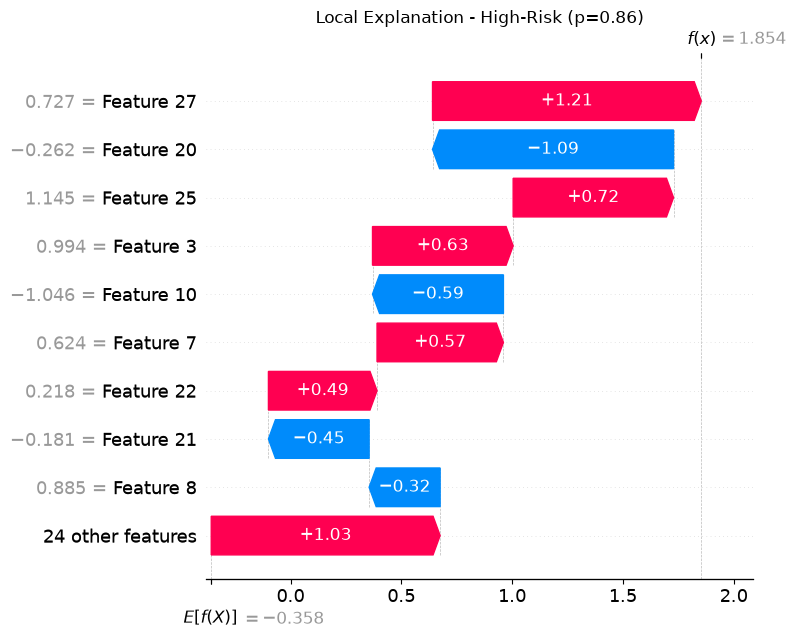

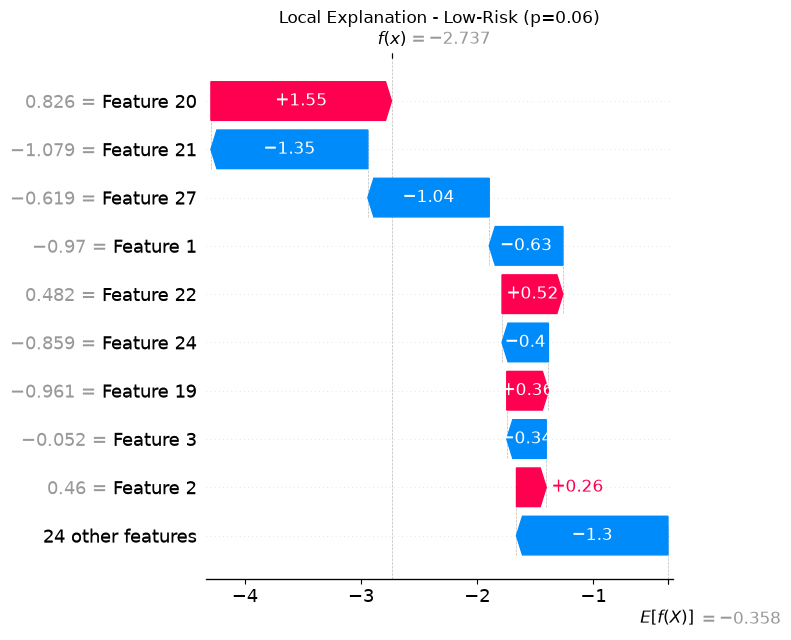

In [15]:
explanation = explainer(X_test_transformed)
probs = xgb_clf.predict_proba(X_test_transformed)[:, 1]
high_idx = int(np.argmin(np.abs(probs - 0.85)))
low_idx = int(np.argmin(np.abs(probs - 0.06)))
print(f"High-risk example: predicted probability = {probs[high_idx]:.3f}")
print(f"Low-risk example: predicted probability = {probs[low_idx]:.3f}")

plt.figure()
shap.plots.waterfall(explanation[high_idx], max_display=10, show=False)
plt.title(f"Local Explanation - High-Risk (p={probs[high_idx]:.2f})")
plt.tight_layout()
plt.show()

plt.figure()
shap.plots.waterfall(explanation[low_idx], max_display=10, show=False)
plt.title(f"Local Explanation - Low-Risk (p={probs[low_idx]:.2f})")
plt.tight_layout()
plt.show()

**Interpretation - short:** The high-risk case is pushed there by large `worst radius`/`worst perimeter` and high `concave points`; the low-risk case shows the same features pulling the opposite way. A handful of size/shape features drive each prediction - easy to explain to a clinician in plain terms ("this tumor's cells are unusually large and irregularly shaped").

## 12. Ethics, Fairness & Limitations

**False negatives vs false positives.** A false negative (malignant tumor scored low-risk) delays treatment - the costlier error in cancer screening. A false positive (benign scored high-risk) causes anxiety and an unnecessary follow-up biopsy, but not direct harm. With the calibrated thresholds in Section 10, Recall now ranges 92%-95% across models - meaning even the best model still misses some real malignant cases on this test set, which is why this tool supports, not replaces, a pathologist's judgment.

**Fairness.** This dataset has **no demographic fields** (age, ethnicity, etc.) - a real limitation, not a strength: no subgroup fairness audit is possible here. Any real deployment would need to collect and audit outcomes across patient subgroups before use.

**Privacy.** Fully de-identified, numeric-only, imaging-derived measurements - no PII.

**Uncertainty & human oversight.** This is a **screening aid, not a diagnosis** - a pathologist must confirm any result via standard biopsy review. The dataset is small (569 samples, 1 institution, 1995 imaging equipment) - Section 5's noise simulation is a proxy for real-world equipment variability, not a substitute for validating on genuinely diverse, current clinical data.

**Limits on deployment.** Do not deploy as-is: needs re-validation on current equipment/populations, a demographic fairness audit once such data is available, and a clear policy that this tool prioritizes cases for human review, never replaces one.

## 13. Save Model Artifacts (for the Streamlit demo app)

In [16]:
import json
import joblib

joblib.dump(logreg_pipe, "bc_model_logreg.pkl")
joblib.dump(rf_search.best_estimator_, "bc_model_rf.pkl")
joblib.dump(best_xgb, "bc_model_xgb_for_shap.pkl")
joblib.dump(stacking_model, "bc_model_stacking.pkl")

metadata = {
    "numeric_features": {}, "categorical_features": {},
    "thresholds": {"rf": 0.38, "xgb": 0.2, "stacking": 0.25},
}
for c in numeric_features:
    metadata["numeric_features"][c] = {
        "min": float(X_train[c].min()), "max": float(X_train[c].max()), "median": float(X_train[c].median()),
    }
for c in categorical_features:
    metadata["categorical_features"][c] = sorted(X_train[c].astype(str).unique().tolist())

with open("bc_feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved bc_model_logreg.pkl, bc_model_rf.pkl, bc_model_xgb_for_shap.pkl, bc_model_stacking.pkl, bc_feature_metadata.json")

Saved bc_model_logreg.pkl, bc_model_rf.pkl, bc_model_xgb_for_shap.pkl, bc_model_stacking.pkl, bc_feature_metadata.json
